# Purpose

Show that MGC scores are enriched in our manualy curated categories

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Brain mgcs content

In [41]:
def load_mgcs(path_to_json, mgcs_name:str)->pd.DataFrame:
	# Load the mgcs dictionary
	# Load the JSON file into a dictionary
	with open(path_to_json, 'r') as json_file:
		mgcs= json.load(json_file)
	# Convert the dictionary to a DataFrame
	mgcs = pd.DataFrame(list(mgcs.items()), columns=['gene', mgcs_name])
	return mgcs


brain_mgcs = pd.read_csv("data/mgc_gini_brain.csv", index_col=0)
brain_mgcs

,mgc_gini
GO:0000045,0.205555
GO:0000070,0.261048
GO:0000077,0.189123
GO:0000079,0.386707
GO:0000082,0.261464
...,...
GO:2001237,0.326138
GO:2001238,0.402848
GO:2001240,0.471196
GO:2001243,0.322552


In [42]:
def load_GO_curations(patho_to_curations="/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/GOCurations.tsv"):
	GO_curations = pd.read_csv(patho_to_curations, sep = "\t")

	def melt_curations(df:pd.DataFrame)->pd.DataFrame:
		"""
		create a new column that is a melted version of the GO term curations

		Parameters:
		- df: pandas DataFrame

		Returns:
		- pandas DataFrame with a new column 'meta' indicating the curation category of the GO term
		"""
		# Create a new column using conditions
		meta = df.apply(lambda row: 'Brain' if row['BrainAffiliated'] == 'T' else 'Non Brain', axis = 1)
		df['meta']=meta
		
		return df
	GO_curations = melt_curations(GO_curations)
	return GO_curations

GO_curations = load_GO_curations()
GO_curations.meta.value_counts()

meta
Non Brain    1294
Brain         102
Name: count, dtype: int64

In [43]:
# Merge the DataFrame with the dictionary DataFrame on 'id'
GO_curations = pd.merge(GO_curations, brain_mgcs, left_on='id', right_index=True)
GO_curations.drop(columns=['PBMCAffiliated'], inplace=True)
GO_curations.to_csv("data/GO_curations_with_mgcs.csv", index=False)
GO_curations.head()

,id,name,namespace,CTAffiliated,BrainAffiliated,def,meta,mgc_gini
0,GO:0000045,autophagosome assembly,biological_process,F,F,The formation of a double membrane-bounded str...,Non Brain,0.205555
1,GO:0000070,mitotic sister chromatid segregation,biological_process,F,F,The cell cycle process in which replicated hom...,Non Brain,0.261048
2,GO:0000077,DNA damage checkpoint signaling,biological_process,F,F,A signal transduction process that contributes...,Non Brain,0.189123
3,GO:0000079,regulation of cyclin-dependent protein serine/...,biological_process,F,F,"Any process that modulates the frequency, rate...",Non Brain,0.386707
4,GO:0000082,G1/S transition of mitotic cell cycle,biological_process,F,F,The mitotic cell cycle transition by which a c...,Non Brain,0.261464


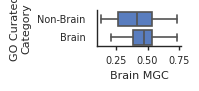

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

def plot_content(GO_curations: pd.DataFrame, xcol: str, ycol: str, title: str, ylabels: list, ylabel: str, savefig: str) -> None:
    """Plot mgcs scores across GO Term Curated categories with publication-ready style."""

    sns.set_theme(style="white")
    sns.set_context("paper")

    palette = sns.color_palette("muted")

    fig, ax = plt.subplots(figsize=(2, 1))

    sns.boxplot(
        data=GO_curations,
        y=ycol,        # categorical axis
        x=xcol,          # numeric axis
        color=palette[0],
        fliersize=0,
        ax=ax
    )

    ax.set_ylabel("GO Curated\nCategory", fontsize=8)
    ax.set_xlabel(ylabel, fontsize=8)

    # IMPORTANT: set y tick labels, not x
    ax.set_yticklabels(ylabels, fontsize=8)
    # Make sure x-axis tick marks show
    ax.tick_params(axis='x', which='both', bottom=True, top=False, length=3)

    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

    sns.despine(ax=ax)
    plt.tight_layout()

    plt.savefig(f"{savefig}.png", dpi=300, transparent=True)
    plt.savefig(f"{savefig}.pdf")
    plt.show()


os.makedirs('figs', exist_ok=True)

plot_content(
    GO_curations=GO_curations,
    xcol='mgc_gini',
    ycol='meta',
    title="",
    ylabels = ["Non-Brain", "Brain"],
    ylabel='Brain MGC',
    savefig="figs/brain_mgcs"
)



# Manuwitney Test

In [45]:
from scipy.stats import mannwhitneyu

# Example: two independent samples
group1 = GO_curations[GO_curations['meta'] == 'Non Brain']['mgc_gini']
group2 = GO_curations[GO_curations['meta'] == 'Brain']['mgc_gini']

# Run the Mann–Whitney U test
stat, p = mannwhitneyu(group1, group2, alternative='two-sided')

print(f"U statistic: {stat}")
print(f"P-value: {p}")
print(f"EFfect Size {group2.mean() - group1.mean()}")

U statistic: 55566.0
P-value: 0.007810681523720972
EFfect Size 0.04467035033418465
